In [237]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [238]:
df = pd.read_csv('online_shoppers_intention.csv')
df.shape

(12330, 18)

In [239]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [240]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [241]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [242]:
df.duplicated().sum()

np.int64(125)

In [243]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [244]:
# Converting to string type
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  object 
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non-null  int64  
 14  TrafficType              12

In [245]:
df['Revenue'].value_counts()

Revenue
0    10297
1     1908
Name: count, dtype: int64

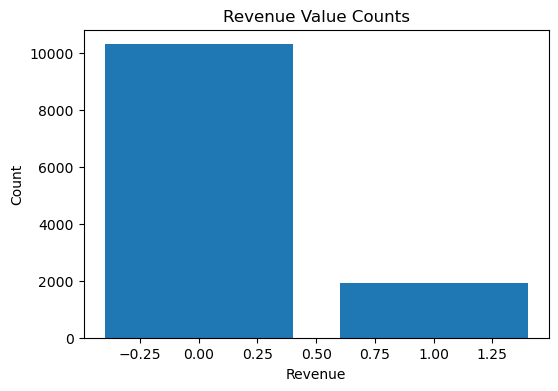

In [246]:
# Bar graph for Revenue value counts
x = df['Revenue'].value_counts().index
y = df['Revenue'].value_counts().values
plt.figure(figsize=(6, 4))
plt.bar(x, y)
plt.xlabel('Revenue')
plt.ylabel('Count')
plt.title('Revenue Value Counts')
plt.show()

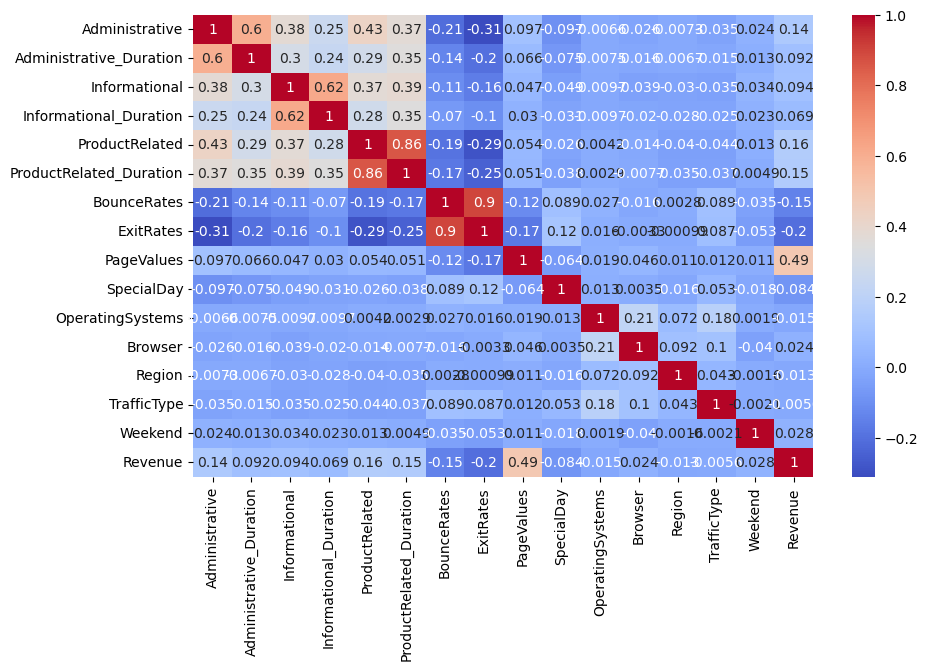

In [247]:
df_numeric = df.select_dtypes(include=[int, float])
plt.figure(figsize=(10, 6))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm')
plt.show()

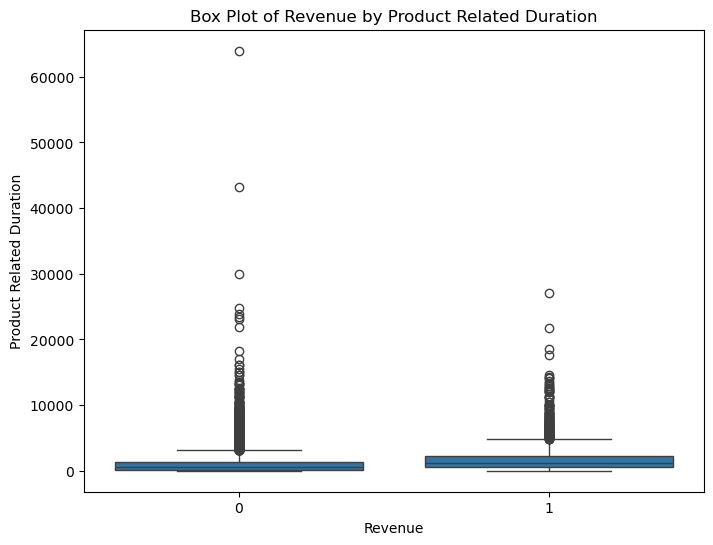

In [248]:
# Box plot 
plt.figure(figsize=(8, 6))
sns.boxplot(x='Revenue', y='ProductRelated_Duration', data=df)
plt.title('Box Plot of Revenue by Product Related Duration')
plt.xlabel('Revenue')
plt.ylabel('Product Related Duration')
plt.show()

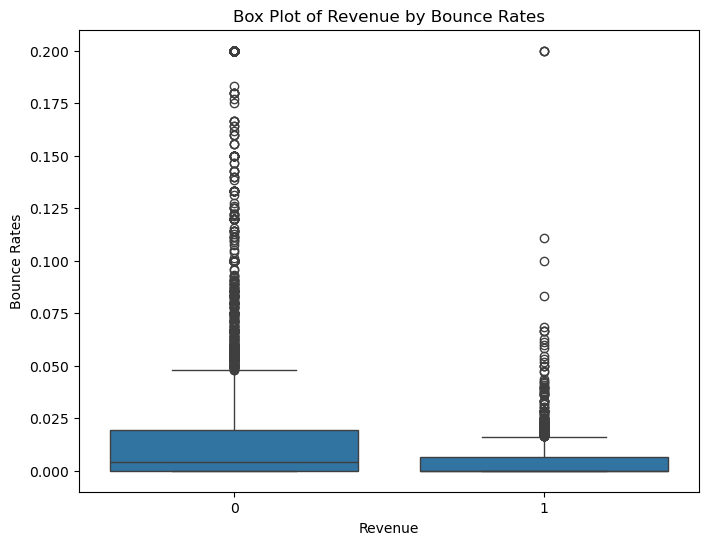

In [249]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Revenue', y='BounceRates', data=df)
plt.title('Box Plot of Revenue by Bounce Rates')
plt.xlabel('Revenue')
plt.ylabel('Bounce Rates')
plt.show()

### Linear Model
- Linear regression

In [250]:
from sklearn.linear_model import LinearRegression
df1 = pd.get_dummies(df, columns=["Month","VisitorType"])

X1 = df1.drop(columns= ["Revenue"])
y1 = df1["Revenue"]


In [251]:
# Split the model
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, mean_absolute_error, recall_score, classification_report, confusion_matrix, r2_score

X_train, X_test, y_train, y_test = train_test_split(X1,y1, test_size= 0.2, random_state= 42, stratify= y1)

# Fit the model
lm_model = LinearRegression()
lm_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [252]:
## Predictions
y_predlm = lm_model.predict(X_test)

print(y_predlm[:5])
print(f"r2: {r2_score(y_test, y_predlm):.4f}")
print(f"\nmean absolute error: {mean_absolute_error(y_test, y_predlm):.4f}")

[ 0.16599691  0.18511505  0.1569794   0.0530417  -0.04828625]
r2: 0.3026

mean absolute error: 0.1997


#### Findings:
From the above linear model the r2 evaluated was really low (0.32) and the predicted values were numbers instead of categories.<br>
This is because we used a **Linear Model** instead of a classifier to predict the outcomes of the analysis.<br>
We then conclude that a linear model is not suitable for prediction of the following problem, using a classifier is the best way to approaching this.<br>

## Classifier Models

In [253]:
## Define Target and features
X = df.drop(columns= ["Revenue"])
y = df["Revenue"]

In [254]:
## Split the data
from sklearn.model_selection import train_test_split, GridSearchCV
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.2, random_state= 42, stratify= y)

## Pipelines

### a). Transformer Pipelines

In [255]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

Numerical_features= X.select_dtypes(include= ["int", "float"]).columns
Categorical_features= X.select_dtypes(include= ["object"]).columns


Numeric_transformer= Pipeline(steps=[
    ("imputer", SimpleImputer(strategy= "median")),
    ("Scaler",StandardScaler())
])

Categorical_transformer= Pipeline(steps=[
    ("Encoder",OneHotEncoder(drop= "first", handle_unknown= "ignore")),
    ("imputer", SimpleImputer(strategy= "most_frequent"))
])


preprocessor = ColumnTransformer(transformers=[
    ("categories", Categorical_transformer, Categorical_features),
    ("numerals", Numeric_transformer, Numerical_features)
])

### b). Model Pipelines
 - LogisticRegression Model,decision tree, random forest, adaboost,svm_model

In [256]:
## Imports
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve

Lr_pipeline = Pipeline(steps=[
    ("Preprocessing", preprocessor),
    ("Classifier", LogisticRegression(
        random_state= 42
    ))
])

Dt_pipeline = Pipeline(steps=[
    ("Preprocessing", preprocessor),
    ("Classifier", DecisionTreeClassifier(
        random_state= 42
    ))
])

Rf_pipeline = Pipeline(steps=[
    ("Preprocessing", preprocessor),
    ("Classifier", RandomForestClassifier(
        random_state= 42
    ))
])

Ab_pipeline = Pipeline(steps=[
    ("Preprocessing", preprocessor),
    ("Classifier", AdaBoostClassifier(
        random_state= 42
    ))
])

Svm_pipeline = Pipeline(steps=[
    ("Preprocessing", preprocessor),
    ("Classifier", SVC(
        probability= True,
        kernel= "rbf"
    ))
])

### 1. Logistic regression

In [257]:
# Fit the model
Lr_pipeline.fit(X_train, y_train)


,steps,"[('Preprocessing', ...), ('Classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categories', ...), ('numerals', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


confusion matrix:
 [[2012   47]
 [ 223  159]]
Classification report:
               precision    recall  f1-score   support

           0       0.90      0.98      0.94      2059
           1       0.77      0.42      0.54       382

    accuracy                           0.89      2441
   macro avg       0.84      0.70      0.74      2441
weighted avg       0.88      0.89      0.88      2441



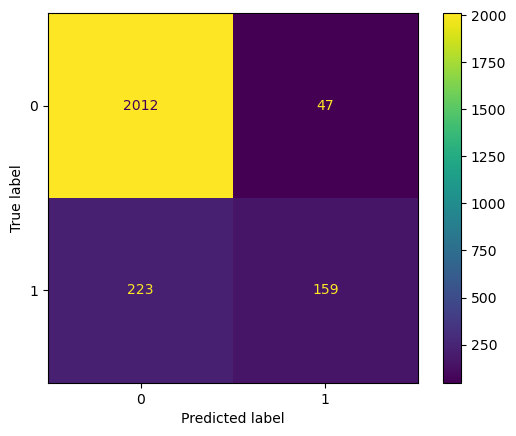

In [258]:
# Predictions

y_predlr = Lr_pipeline.predict(X_test)
y_pred_probalr = Lr_pipeline.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_predlr)

print(f"confusion matrix:\n {cm}")

cmd = ConfusionMatrixDisplay(confusion_matrix=cm)
cmd.plot()

print(f"Classification report:\n {classification_report(y_test, y_predlr)}")


In [259]:
## Use grid search to improve the model

Lr_param_grid = {
    "Classifier__class_weight":["balanced"],
    "Classifier__max_iter": [1000, 2000]
}

Lr_grid_search = GridSearchCV(
    Lr_pipeline,
    param_grid= Lr_param_grid,
    cv= StratifiedKFold(n_splits=5),
    n_jobs= -1,
    scoring= "recall"
)

Lr_grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'Classifier__class_weight': ['balanced'], 'Classifier__max_iter': [1000, 2000]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('categories', ...), ('numerals', ...)]"


confusion matrix:
 [[1778  281]
 [  81  301]]
Classification report:
               precision    recall  f1-score   support

           0       0.96      0.86      0.91      2059
           1       0.52      0.79      0.62       382

    accuracy                           0.85      2441
   macro avg       0.74      0.83      0.77      2441
weighted avg       0.89      0.85      0.86      2441



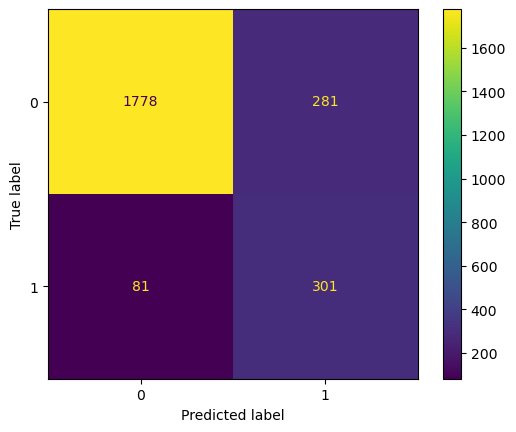

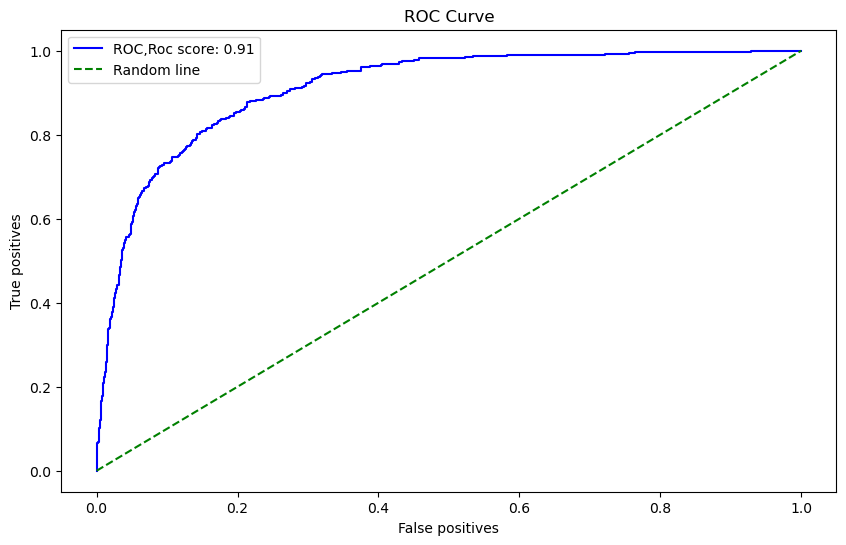

In [260]:
# Predictions

best_params = Lr_grid_search.best_params_
lr_model = Lr_grid_search.best_estimator_

y_predlr = lr_model.predict(X_test)
y_pred_probalr = lr_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_predlr)

print(f"confusion matrix:\n {cm}")

cmd = ConfusionMatrixDisplay(confusion_matrix=cm)
cmd.plot()

print(f"Classification report:\n {classification_report(y_test, y_predlr)}")

# Roc scores
fpr, tpr, threshold = roc_curve(y_test== 1, y_pred_probalr)

roc_scorelr = roc_auc_score(y_test== 1, y_pred_probalr)


## Plot roc curve
plt.figure(figsize= (10,6))
plt.plot(fpr, tpr, color= "blue", label= f"ROC,Roc score: {roc_scorelr:.2f}")
plt.plot([0,1], [0,1], color= "green", linestyle= "--", label= "Random line")
plt.title("ROC Curve")
plt.xlabel("False positives")
plt.ylabel("True positives")
plt.legend()
plt.show()


## 2. Decision Tree

In [261]:
# Fit the model
Dt_pipeline.fit(X_train, y_train)

,steps,"[('Preprocessing', ...), ('Classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categories', ...), ('numerals', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


confusion matrix:
 [[1881  178]
 [ 164  218]]
Classification report:
               precision    recall  f1-score   support

           0       0.92      0.91      0.92      2059
           1       0.55      0.57      0.56       382

    accuracy                           0.86      2441
   macro avg       0.74      0.74      0.74      2441
weighted avg       0.86      0.86      0.86      2441



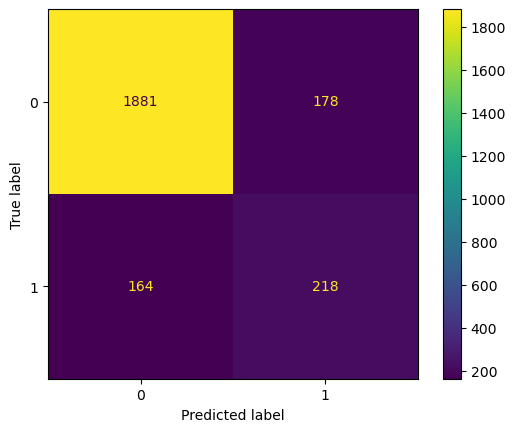

In [262]:
## Predictions
y_preddt = Dt_pipeline.predict(X_test)
y_pred_probadt = Dt_pipeline.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_preddt)

print(f"confusion matrix:\n {cm}")

cmd = ConfusionMatrixDisplay(confusion_matrix=cm)
cmd.plot()

print(f"Classification report:\n {classification_report(y_test, y_preddt)}")


In [263]:
## Tuning with grid search

Dt_param_grid = {
    "Classifier__max_depth": [2, 3, 5],
    "Classifier__min_samples_split": [10, 20, 30],
    "Classifier__min_samples_leaf": [5, 10, 20],
    "Classifier__class_weight": ["balanced"],
    "Classifier__criterion": ["gini", "entropy"]
}

dt_grid_search = GridSearchCV(
    Dt_pipeline,
    param_grid= Dt_param_grid,
    cv= StratifiedKFold(n_splits=5),
    n_jobs= -1,
    scoring= "recall"
)

dt_grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'Classifier__class_weight': ['balanced'], 'Classifier__criterion': ['gini', 'entropy'], 'Classifier__max_depth': [2, 3, ...], 'Classifier__min_samples_leaf': [5, 10, ...], ...}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('categories', ...), ('numerals', ...)]"


confusion matrix:
 [[1740  319]
 [  53  329]]
Classification report:
               precision    recall  f1-score   support

           0       0.97      0.85      0.90      2059
           1       0.51      0.86      0.64       382

    accuracy                           0.85      2441
   macro avg       0.74      0.85      0.77      2441
weighted avg       0.90      0.85      0.86      2441



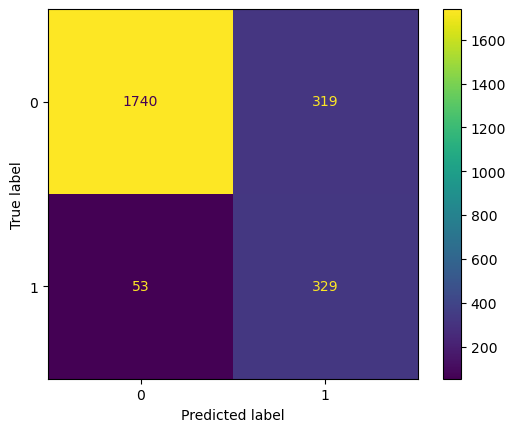

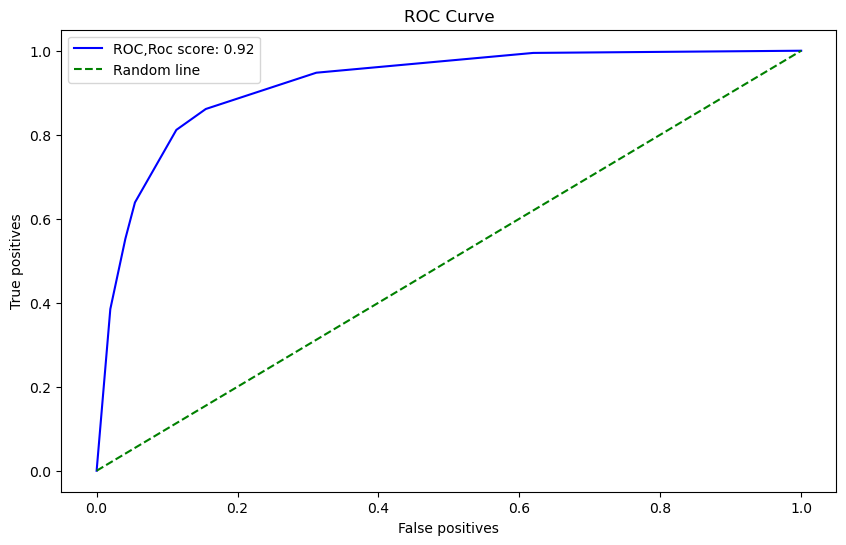

In [264]:
# Predictions
best_params = dt_grid_search.best_params_
dtmodel = dt_grid_search.best_estimator_

y_preddt = dtmodel.predict(X_test)
y_pred_probadt = dtmodel.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_preddt)

print(f"confusion matrix:\n {cm}")

cmd = ConfusionMatrixDisplay(confusion_matrix=cm)
cmd.plot()

print(f"Classification report:\n {classification_report(y_test, y_preddt)}")



# Roc scores
fpr, tpr, threshold = roc_curve(y_test== 1, y_pred_probadt)

roc_scorelr = roc_auc_score(y_test== 1, y_pred_probadt)


## Plot roc curve
plt.figure(figsize= (10,6))
plt.plot(fpr, tpr, color= "blue", label= f"ROC,Roc score: {roc_scorelr:.2f}")
plt.plot([0,1], [0,1], color= "green", linestyle= "--", label= "Random line")
plt.title("ROC Curve")
plt.xlabel("False positives")
plt.ylabel("True positives")
plt.legend()
plt.show()


### 3. Random Forest

In [265]:
## fit the model
Rf_pipeline.fit(X_train, y_train)

,steps,"[('Preprocessing', ...), ('Classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categories', ...), ('numerals', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


confusion matrix:
 [[1987   72]
 [ 157  225]]
Classification report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95      2059
           1       0.76      0.59      0.66       382

    accuracy                           0.91      2441
   macro avg       0.84      0.78      0.80      2441
weighted avg       0.90      0.91      0.90      2441



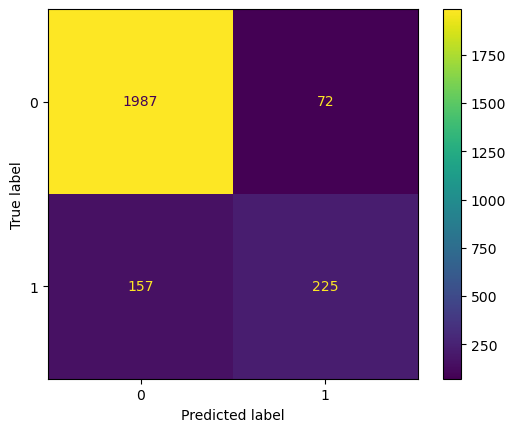

In [266]:
## predictions
y_predrf = Rf_pipeline.predict(X_test)
y_pred_probarf = Rf_pipeline.predict_proba(X_test)[:, 1]


cm = confusion_matrix(y_test, y_predrf)

print(f"confusion matrix:\n {cm}")

cmd = ConfusionMatrixDisplay(confusion_matrix=cm)
cmd.plot()

print(f"Classification report:\n {classification_report(y_test, y_predrf)}")


In [267]:
## Tuning using gridsearch

rf_param_grid = {
    "Classifier__n_estimators":[100, 200, 300],
    "Classifier__max_depth":[2, 3, 5],
    "Classifier__min_samples_split":[10, 20, 30],
    "Classifier__min_samples_leaf":[5, 10, 20],
    "Classifier__class_weight": ["balanced"]
}

rf_grid_search = GridSearchCV(
    Rf_pipeline,
    param_grid= rf_param_grid,
    cv=StratifiedKFold(n_splits=5),
    n_jobs= -1,
    scoring= "recall"
)

rf_grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'Classifier__class_weight': ['balanced'], 'Classifier__max_depth': [2, 3, ...], 'Classifier__min_samples_leaf': [5, 10, ...], 'Classifier__min_samples_split': [10, 20, ...], ...}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('categories', ...), ('numerals', ...)]"


confusion matrix:
 [[1776  283]
 [  60  322]]
Classification report:
               precision    recall  f1-score   support

           0       0.97      0.86      0.91      2059
           1       0.53      0.84      0.65       382

    accuracy                           0.86      2441
   macro avg       0.75      0.85      0.78      2441
weighted avg       0.90      0.86      0.87      2441



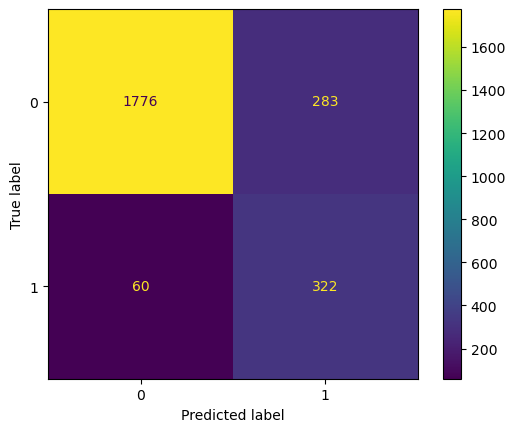

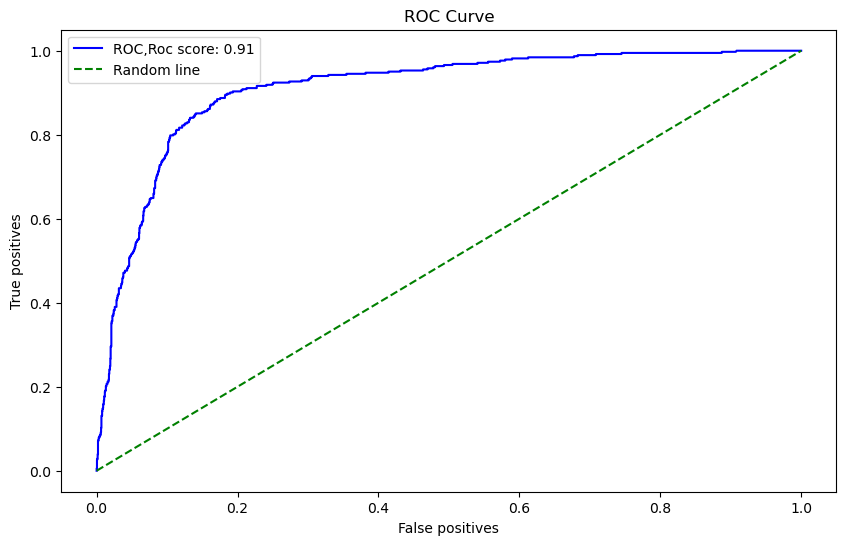

In [268]:
## predictions

rfmodel = rf_grid_search.best_estimator_
best_params = rf_grid_search.best_params_
y_predrf = rfmodel.predict(X_test)
y_pred_probarf = rfmodel.predict_proba(X_test)[:, 1]


cm = confusion_matrix(y_test, y_predrf)

print(f"confusion matrix:\n {cm}")

cmd = ConfusionMatrixDisplay(confusion_matrix=cm)
cmd.plot()

print(f"Classification report:\n {classification_report(y_test, y_predrf)}")



# Roc scores
fpr, tpr, threshold = roc_curve(y_test== 1, y_pred_probarf)

roc_scorerf = roc_auc_score(y_test== 1, y_pred_probarf)


## Plot roc curve
plt.figure(figsize= (10,6))
plt.plot(fpr, tpr, color= "blue", label= f"ROC,Roc score: {roc_scorerf:.2f}")
plt.plot([0,1], [0,1], color= "green", linestyle= "--", label= "Random line")
plt.title("ROC Curve")
plt.xlabel("False positives")
plt.ylabel("True positives")
plt.legend()
plt.show()


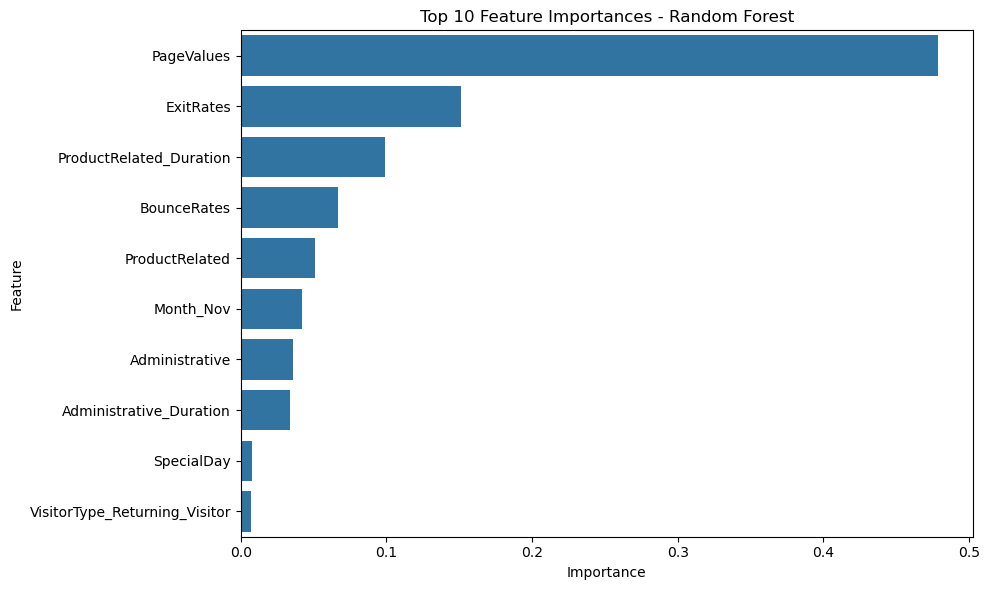

In [269]:
# Get feature names after preprocessing
rf_preprocessor = rfmodel.named_steps['Preprocessing']
cat_features = rf_preprocessor.transformers_[0][1]\
    .named_steps['Encoder'].get_feature_names_out(Categorical_features)
all_features = list(cat_features) + list(Numerical_features)

# Get importances
importances = rfmodel.named_steps['Classifier'].feature_importances_
feat_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title('Top 10 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

### 4. AdaBoost Classifier

In [270]:
## Fit the model
Ab_pipeline.fit(X_train, y_train)

,steps,"[('Preprocessing', ...), ('Classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categories', ...), ('numerals', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


confusion matrix:
 [[1957  102]
 [ 146  236]]
Classification report:
               precision    recall  f1-score   support

           0       0.93      0.95      0.94      2059
           1       0.70      0.62      0.66       382

    accuracy                           0.90      2441
   macro avg       0.81      0.78      0.80      2441
weighted avg       0.89      0.90      0.90      2441



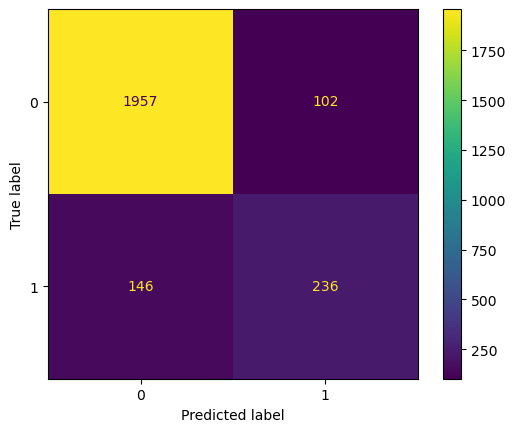

In [271]:
## predictions
y_predab = Ab_pipeline.predict(X_test)
y_pred_probaab = Ab_pipeline.predict_proba(X_test)[:, 1]


cm = confusion_matrix(y_test, y_predab)

print(f"confusion matrix:\n {cm}")

cmd = ConfusionMatrixDisplay(confusion_matrix=cm)
cmd.plot()

print(f"Classification report:\n {classification_report(y_test, y_predab)}")

In [272]:
# Tuning using grid search
ab_param_grid = {
    "Classifier__n_estimators": [10, 20, 50],
    "Classifier__learning_rate": [1, 0.1,0.01]
}

ab_grid_search = GridSearchCV(
    Ab_pipeline,
    cv = StratifiedKFold(n_splits=5),
    param_grid= ab_param_grid,
    n_jobs= -1,
    scoring= "recall"
)

ab_grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'Classifier__learning_rate': [1, 0.1, ...], 'Classifier__n_estimators': [10, 20, ...]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('categories', ...), ('numerals', ...)]"


confusion matrix:
 [[1836  223]
 [  77  305]]
Classification report:
               precision    recall  f1-score   support

           0       0.96      0.89      0.92      2059
           1       0.58      0.80      0.67       382

    accuracy                           0.88      2441
   macro avg       0.77      0.85      0.80      2441
weighted avg       0.90      0.88      0.88      2441



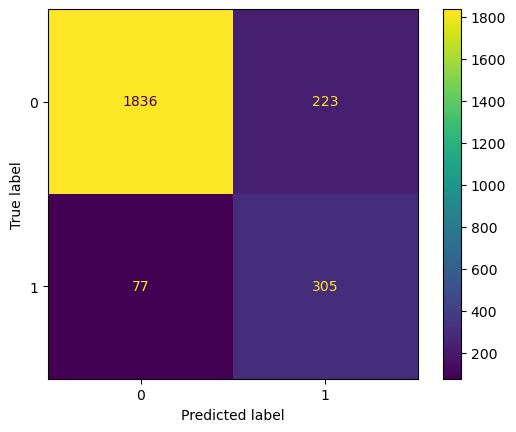

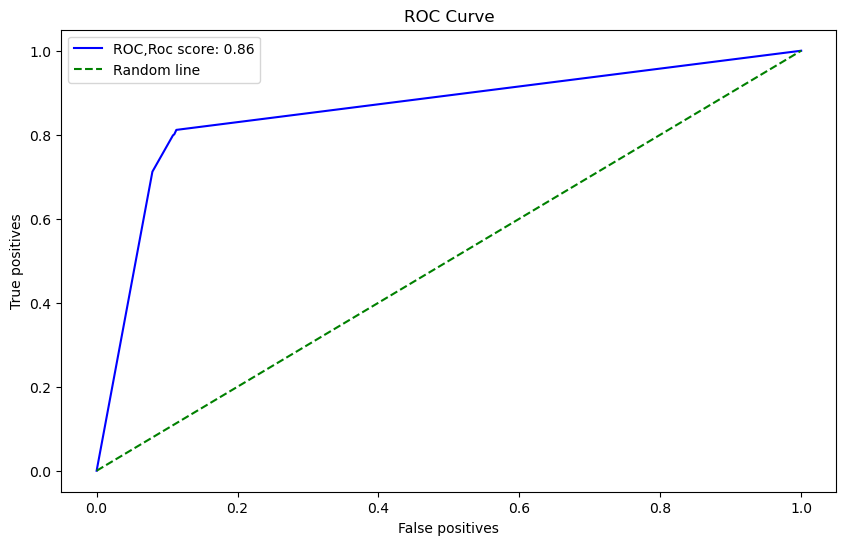

In [273]:
## predictions

abmodel = ab_grid_search.best_estimator_
best_params = ab_grid_search.best_params_
y_predab = abmodel.predict(X_test)
y_pred_probaab = abmodel.predict_proba(X_test)[:, 1]


cm = confusion_matrix(y_test, y_predab)

print(f"confusion matrix:\n {cm}")

cmd = ConfusionMatrixDisplay(confusion_matrix=cm)
cmd.plot()

print(f"Classification report:\n {classification_report(y_test, y_predab)}")



# Roc scores
fpr, tpr, threshold = roc_curve(y_test== 1, y_pred_probaab)

roc_scoreab = roc_auc_score(y_test== 1, y_pred_probaab)


## Plot roc curve
plt.figure(figsize= (10,6))
plt.plot(fpr, tpr, color= "blue", label= f"ROC,Roc score: {roc_scoreab:.2f}")
plt.plot([0,1], [0,1], color= "green", linestyle= "--", label= "Random line")
plt.title("ROC Curve")
plt.xlabel("False positives")
plt.ylabel("True positives")
plt.legend()
plt.show()

### 5. SVM Classifier

In [274]:
# Fit the model
Svm_pipeline.fit(X_train, y_train)

,steps,"[('Preprocessing', ...), ('Classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categories', ...), ('numerals', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


confusion matrix:
 [[1989   70]
 [ 187  195]]
Classification report:
               precision    recall  f1-score   support

           0       0.91      0.97      0.94      2059
           1       0.74      0.51      0.60       382

    accuracy                           0.89      2441
   macro avg       0.82      0.74      0.77      2441
weighted avg       0.89      0.89      0.89      2441



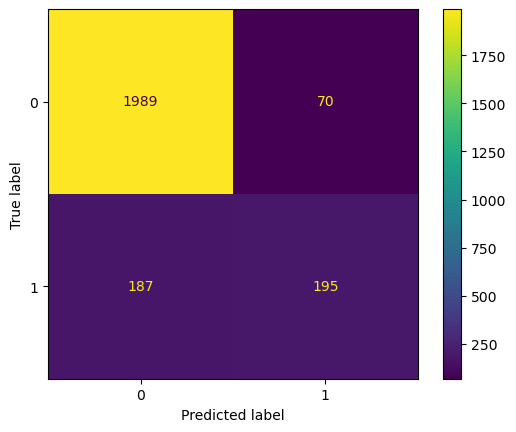

In [275]:
## predictions
y_predsvm = Svm_pipeline.predict(X_test)
y_pred_probasvm = Svm_pipeline.predict_proba(X_test)[:, 1]


cm = confusion_matrix(y_test, y_predsvm)

print(f"confusion matrix:\n {cm}")

cmd = ConfusionMatrixDisplay(confusion_matrix=cm)
cmd.plot()

print(f"Classification report:\n {classification_report(y_test, y_predsvm)}")

In [276]:
# Tuning using grid search

svm_param_grid = {
    "Classifier__C": [0.1, 1, 10],
    "Classifier__gamma": [1, 0.1, 0.01],
    "Classifier__class_weight": ["balanced"]
}

svm_grid_search = GridSearchCV(
    Svm_pipeline,
    param_grid= svm_param_grid,
    n_jobs= -1,
    cv= StratifiedKFold(n_splits=5),
    scoring= "recall"
)

svm_grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...ility=True))])
,param_grid,"{'Classifier__C': [0.1, 1, ...], 'Classifier__class_weight': ['balanced'], 'Classifier__gamma': [1, 0.1, ...]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('categories', ...), ('numerals', ...)]"


confusion matrix:
 [[ 689 1370]
 [  15  367]]
Classification report:
               precision    recall  f1-score   support

           0       0.98      0.33      0.50      2059
           1       0.21      0.96      0.35       382

    accuracy                           0.43      2441
   macro avg       0.59      0.65      0.42      2441
weighted avg       0.86      0.43      0.47      2441



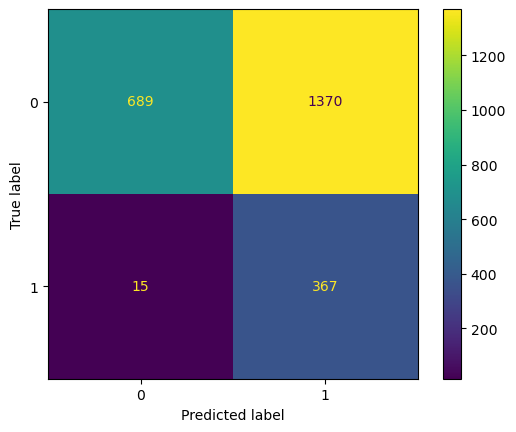

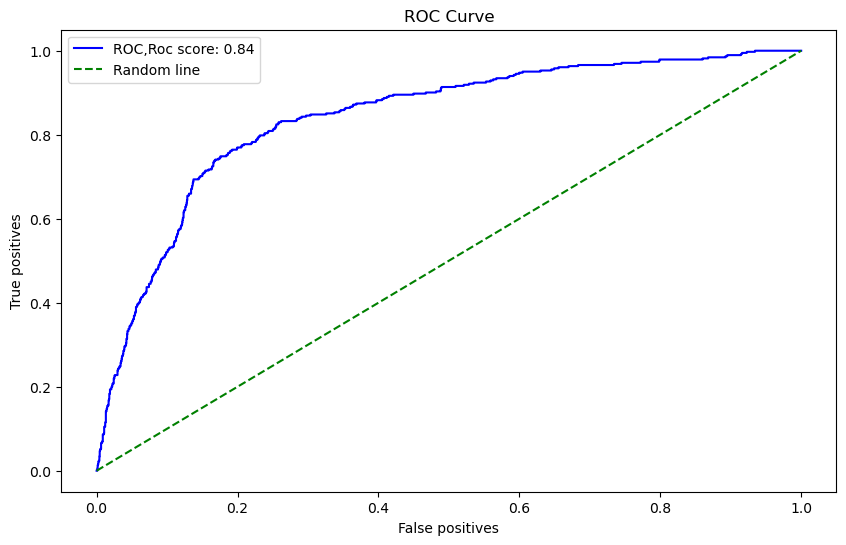

In [277]:
## predictions

svmmodel = svm_grid_search.best_estimator_
best_params = svm_grid_search.best_params_
y_predsvm = svmmodel.predict(X_test)
y_pred_probasvm = svmmodel.predict_proba(X_test)[:, 1]


cm = confusion_matrix(y_test, y_predsvm)

print(f"confusion matrix:\n {cm}")

cmd = ConfusionMatrixDisplay(confusion_matrix=cm)
cmd.plot()

print(f"Classification report:\n {classification_report(y_test, y_predsvm)}")



# Roc scores
fpr, tpr, threshold = roc_curve(y_test== 1, y_pred_probasvm)

roc_scoresvm = roc_auc_score(y_test== 1, y_pred_probasvm)


## Plot roc curve
plt.figure(figsize= (10,6))
plt.plot(fpr, tpr, color= "blue", label= f"ROC,Roc score: {roc_scoresvm:.2f}")
plt.plot([0,1], [0,1], color= "green", linestyle= "--", label= "Random line")
plt.title("ROC Curve")
plt.xlabel("False positives")
plt.ylabel("True positives")
plt.legend()
plt.show()

### Final model table comparisons

In [278]:

model_results = {
    'Logistic Regression': {
        'model': lr_model, 'y_pred': y_predlr, 'y_proba': y_pred_probalr
    },
    'Decision Tree': {
        'model': dtmodel, 'y_pred': y_preddt, 'y_proba': y_pred_probadt
    },
    'Random Forest': {
        'model': rfmodel, 'y_pred': y_predrf, 'y_proba': y_pred_probarf
    },
    'AdaBoost': {
        'model': abmodel, 'y_pred': y_predab, 'y_proba': y_pred_probaab
    },
    'SVM': {
        'model': svmmodel, 'y_pred': y_predsvm, 'y_proba': y_pred_probasvm
    }
}

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rows = []
for name, m in model_results.items():
    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, m['y_pred']),
        'Precision': precision_score(y_test, m['y_pred']),
        'Recall': recall_score(y_test, m['y_pred']),
        'F1 Score': f1_score(y_test, m['y_pred']),
        'ROC-AUC': roc_auc_score(y_test, m['y_proba'])
    })

results_df = pd.DataFrame(rows).set_index('Model').round(4)
results_df.style.highlight_max(color='lightgreen').format("{:.4f}")

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8517,0.5172,0.7880,0.6245,0.9108
Decision Tree,0.8476,0.5077,0.8613,0.6388,0.9196
Random Forest,0.8595,0.5322,0.8429,0.6525,0.9098
AdaBoost,0.8771,0.5777,0.7984,0.6703,0.8574
SVM,0.4326,0.2113,0.9607,0.3464,0.8403
